<a href="https://colab.research.google.com/github/Chinki021/Fairness-and-Explainability-Audit-of-Credit-Card-Fraud-Detection-Models/blob/main/Fairness_and_Explainability_Audit_of_Credit_Card_Fraud_Detection_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap lime fairlearn lightgbm xgboost imbalanced-learn scikit-learn matplotlib seaborn pandas numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 8.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek


from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, matthews_corrcoef
)


import shap
import lime
import lime.lime_tabular


from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference,
    equalized_odds_difference, selection_rate
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity


from IPython.display import display
shap.initjs()

print("All libraries loaded successfully!")

All libraries loaded successfully!


DATASET OVERVIEW
Shape: (284807, 31)
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate: 0.1727%

Missing Values: 0


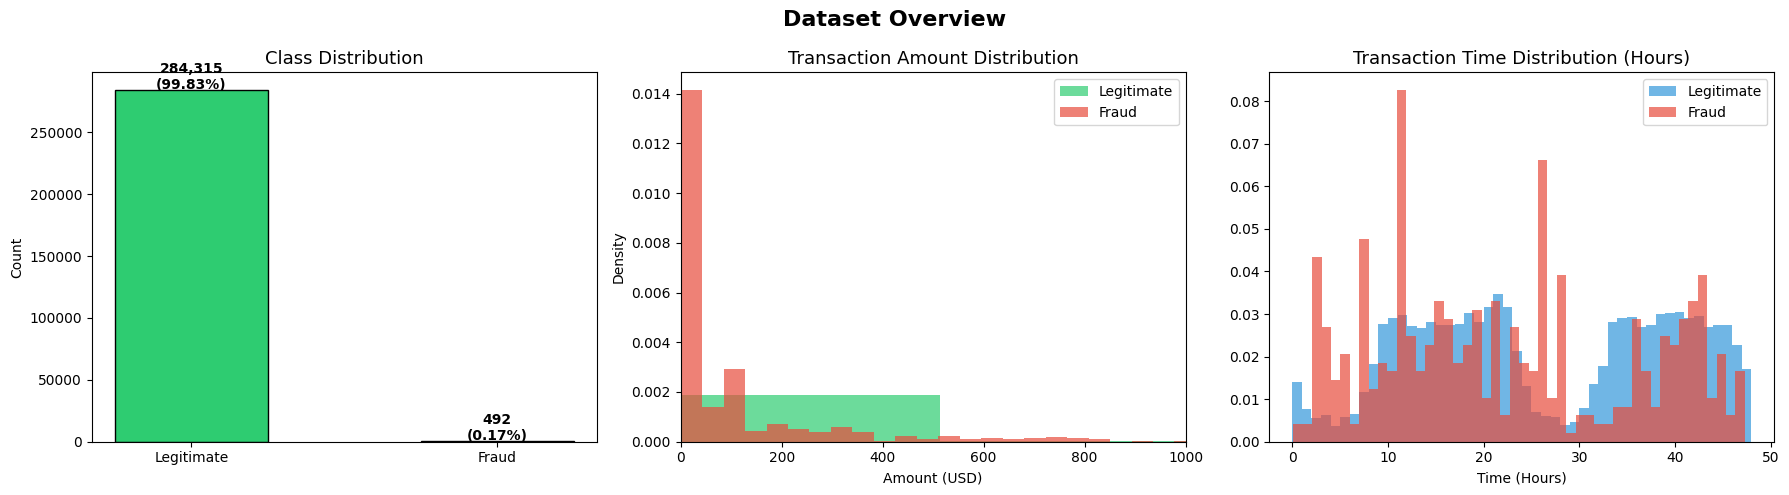

Figure 1 saved.


In [3]:
df = pd.read_csv('creditcard.csv')

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape}")
print(f"Features: {df.columns.tolist()}")
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Rate: {df['Class'].mean()*100:.4f}%")
print(f"\nMissing Values: {df.isnull().sum().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.2f}%)',ha='center', fontweight='bold')

axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7,color='#2ecc71', label='Legitimate', density=True)
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7,color='#e74c3c', label='Fraud', density=True)
axes[1].set_title('Transaction Amount Distribution', fontsize=13)
axes[1].set_xlabel('Amount (USD)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_xlim(0, 1000)

axes[2].hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.7,color='#3498db', label='Legitimate', density=True)
axes[2].hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.7,color='#e74c3c', label='Fraud', density=True)
axes[2].set_title('Transaction Time Distribution (Hours)', fontsize=13)
axes[2].set_xlabel('Time (Hours)')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig1_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

Feature Engineering + Preprocessing

In [4]:
df['Hour'] = (df['Time'] % 86400) // 3600
df['Amount_log'] = np.log1p(df['Amount'])
df['Amount_squared'] = df['Amount'] ** 2

df['spending_group'] = pd.qcut(df['Amount'], q=3,labels=['Low-spend', 'Mid-spend', 'High-spend'])

print("Spending Group Distribution:")
print(df.groupby('spending_group')['Class'].agg(['count', 'sum', 'mean']).rename(columns={'count': 'Total', 'sum': 'Frauds', 'mean': 'Fraud Rate'}))

drop_cols = ['Time', 'Amount', 'spending_group']
feature_cols = [c for c in df.columns if c not in drop_cols + ['Class']]

X = df[feature_cols].values
y = df['Class'].values
sensitive_feature = df['spending_group'].values

print(f"\n Features used: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature,test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Applying SMOTETomek resampling...")
smote_tomek = SMOTETomek(random_state=42, n_jobs=-1)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_scaled, y_train)

print(f"Before resampling:{np.bincount(y_train)}")
print(f"After resampling:{np.bincount(y_train_resampled)}")
print("Resampling complete.")

Spending Group Distribution:
                Total  Frauds  Fraud Rate
spending_group                           
Low-spend       97314     249    0.002559
Mid-spend       93731      57    0.000608
High-spend      93762     186    0.001984

 Features used: 31
Feature list: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'Amount_log', 'Amount_squared']

 Applying SMOTETomek resampling...
Before resampling:[227451    394]
After resampling:[227451 227451]
Resampling complete.


train all models

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',C=0.1, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15,class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),use_label_encoder=False, eval_metric='aucpr',random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,is_unbalance=True, random_state=42,n_jobs=-1, verbose=-1),}

#Train & Evaluate
results = {}
trained_models = {}

print("="*50)
print("TRAINING ALL MODELS")
print("="*50)

for name, model in models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'f1': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'report': classification_report(y_test, y_pred,target_names=['Legitimate', 'Fraud'])}

    print(f" F1: {results[name]['f1']:.4f} | "
          f"AUC-ROC: {results[name]['auc_roc']:.4f} | "
          f"Avg Precision: {results[name]['avg_precision']:.4f} | "
          f"MCC: {results[name]['mcc']:.4f}")

print("\n All models trained successfully!")

TRAINING ALL MODELS

  Training Logistic Regression...
 F1: 0.1040 | AUC-ROC: 0.9711 | Avg Precision: 0.7188 | MCC: 0.2214

  Training Random Forest...
 F1: 0.7421 | AUC-ROC: 0.9847 | Avg Precision: 0.8489 | MCC: 0.7464

  Training XGBoost...
 F1: 0.2638 | AUC-ROC: 0.9820 | Avg Precision: 0.8422 | MCC: 0.3671

  Training LightGBM...
 F1: 0.7623 | AUC-ROC: 0.9748 | Avg Precision: 0.8608 | MCC: 0.7675

 All models trained successfully!


evaluation plots

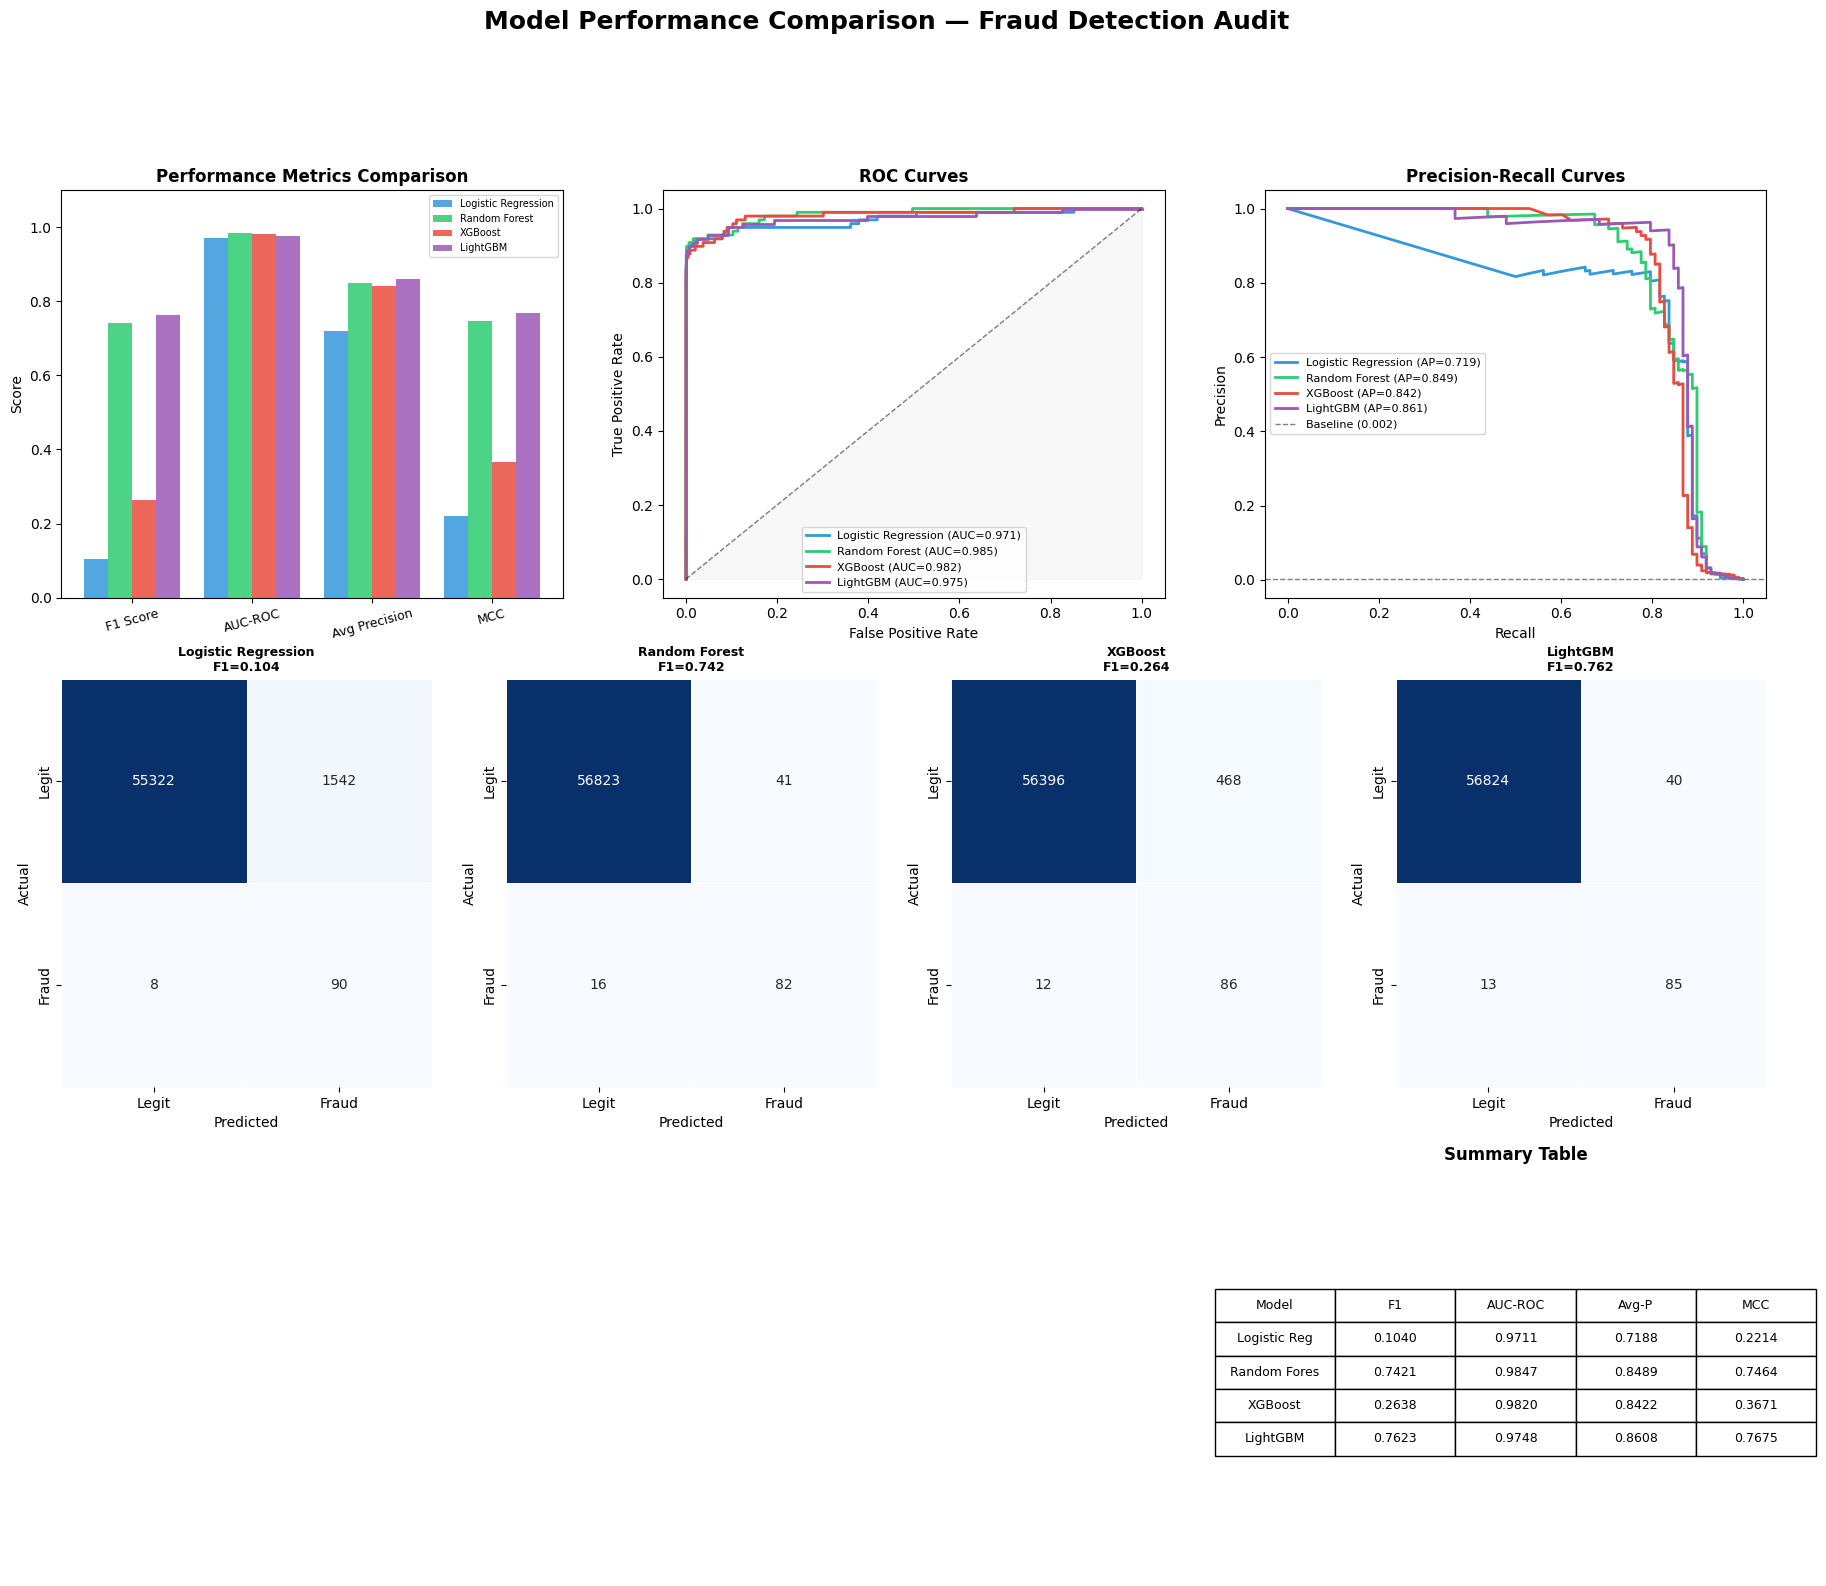

 Figure 2 saved.


In [7]:
fig = plt.figure(figsize=(22, 18))
fig.suptitle('Model Performance Comparison — Fraud Detection Audit',fontsize=18, fontweight='bold', y=0.98)

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
model_names = list(results.keys())

ax1 = fig.add_subplot(3, 3, 1)
metrics = ['f1', 'auc_roc', 'avg_precision', 'mcc']
metric_labels = ['F1 Score', 'AUC-ROC', 'Avg Precision', 'MCC']
x = np.arange(len(metrics))
width = 0.2

for i, (name, color) in enumerate(zip(model_names, colors)):
  vals = [results[name][m] for m in metrics]
  bars = ax1.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85)

ax1.set_xticks(x + width*1.5)
ax1.set_xticklabels(metric_labels, rotation=15, fontsize=9)
ax1.set_ylim(0, 1.1)
ax1.set_title('Performance Metrics Comparison', fontweight='bold')
ax1.legend(fontsize=7)
ax1.set_ylabel('Score')

ax2 = fig.add_subplot(3, 3, 2)
for (name, color) in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax2.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC={results[name]['auc_roc']:.3f})")
ax2.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
ax2.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax2.set_title('ROC Curves', fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(3, 3, 3)
for (name, color) in zip(model_names, colors):
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_prob'])
    ap = results[name]['avg_precision']
    ax3.plot(rec, prec, color=color, lw=2,
             label=f"{name} (AP={ap:.3f})")
ax3.axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1,
            label=f'Baseline ({y_test.mean():.3f})')
ax3.set_title('Precision-Recall Curves', fontweight='bold')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(fontsize=8)

for idx, (name, color) in enumerate(zip(model_names, colors)):
    ax = fig.add_subplot(3, 4, idx+5)
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'],
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\nF1={results[name]["f1"]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

ax8 = fig.add_subplot(3, 3, 9)
ax8.axis('off')
table_data = []
for name in model_names:
    table_data.append([
        name[:12],
        f"{results[name]['f1']:.4f}",
        f"{results[name]['auc_roc']:.4f}",
        f"{results[name]['avg_precision']:.4f}",
        f"{results[name]['mcc']:.4f}"
    ])

table = ax8.table(
    cellText=table_data,
    colLabels=['Model', 'F1', 'AUC-ROC', 'Avg-P', 'MCC'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2)
ax8.set_title('Summary Table', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 2 saved.")

SHAP Explainability (Best Model)

 Best Model: Random Forest | AUC-ROC: 0.9847
 Computing SHAP values 
 SHAP values computed!


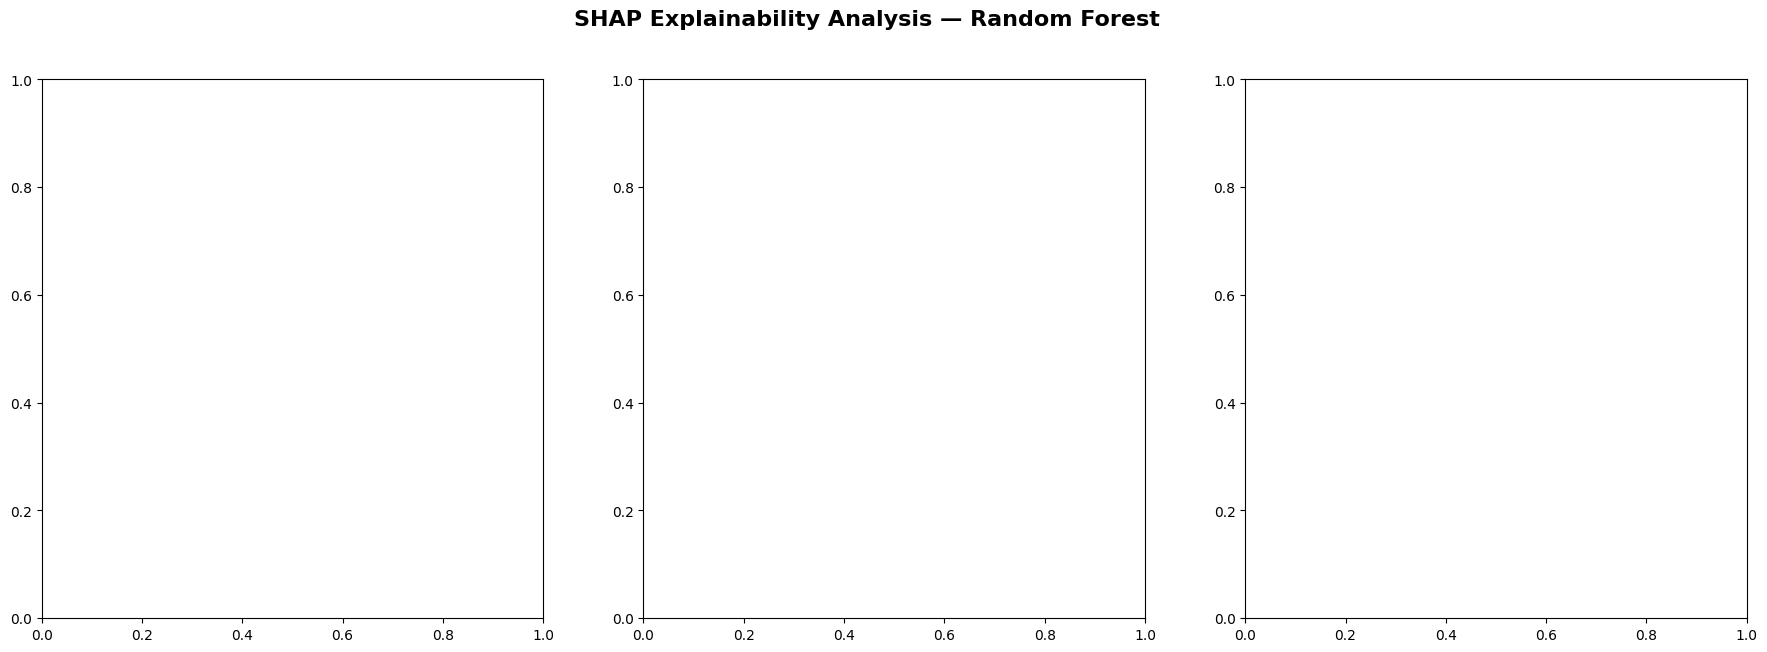

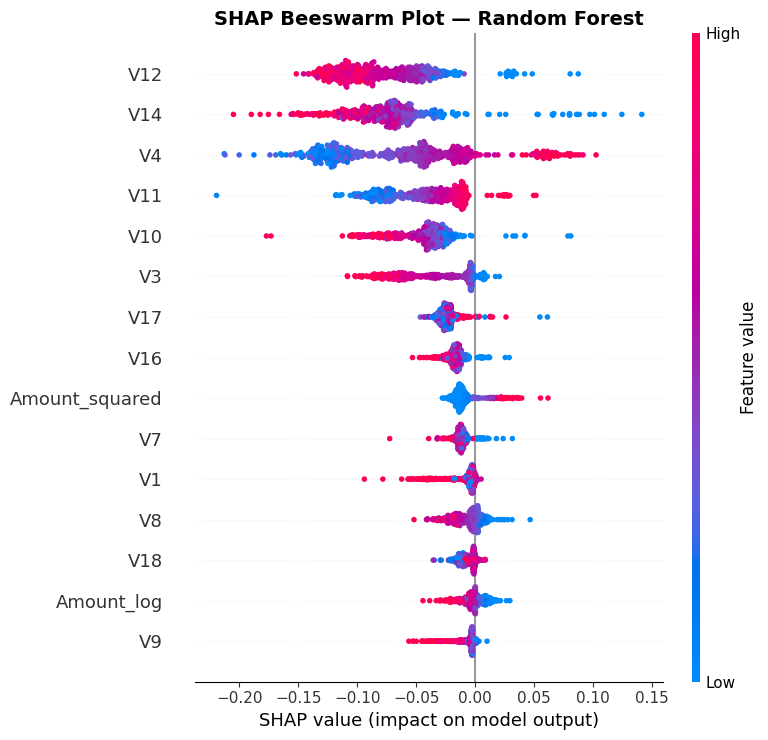

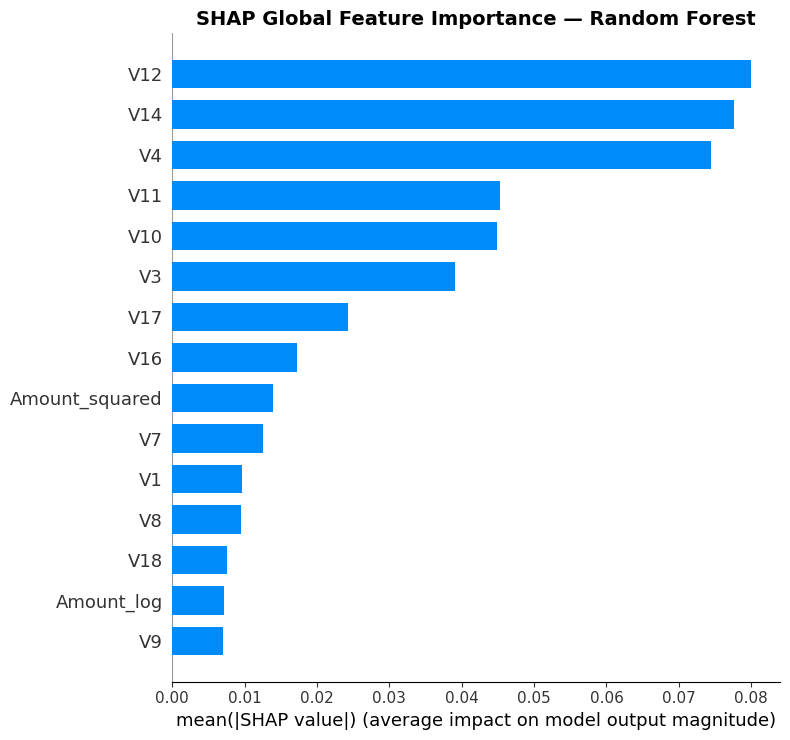

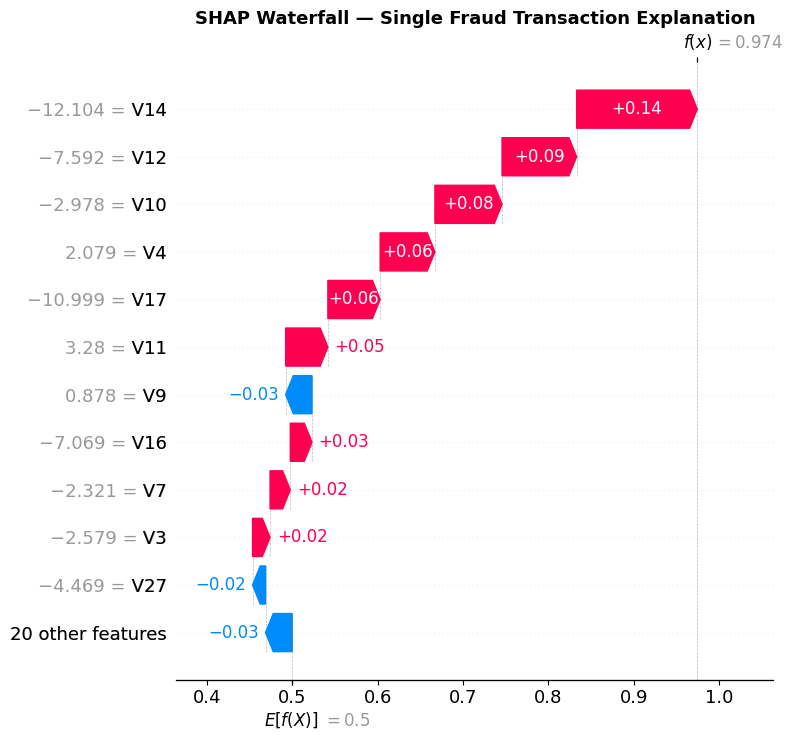

SHAP analysis complete. Figures 3a, 3b, 3c saved.


In [9]:
best_model_name = max(results, key=lambda x: results[x]['auc_roc'])
best_model = trained_models[best_model_name]
print(f" Best Model: {best_model_name} | AUC-ROC: {results[best_model_name]['auc_roc']:.4f}")

print(" Computing SHAP values ")

explainer = shap.TreeExplainer(best_model)

sample_idx = np.random.choice(len(X_test_scaled), size=500, replace=False)
X_sample = X_test_scaled[sample_idx]
y_sample = y_test[sample_idx]

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):

    sv_for_plot = shap_values[1]
    expected_value_for_plot = explainer.expected_value[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:

    sv_for_plot = shap_values[:, :, 1]
    expected_value_for_plot = explainer.expected_value[1]
else:

    sv_for_plot = shap_values
    expected_value_for_plot = explainer.expected_value

feature_names = feature_cols

print(" SHAP values computed!")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'SHAP Explainability Analysis — {best_model_name}',fontsize=16, fontweight='bold')

plt.figure(figsize=(10, 8))
shap.summary_plot(sv_for_plot, X_sample, feature_names=feature_names,plot_type='dot', show=False, max_display=15)
plt.title(f'SHAP Beeswarm Plot — {best_model_name}',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3a_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(sv_for_plot, X_sample, feature_names=feature_names,plot_type='bar', show=False, max_display=15)
plt.title(f'SHAP Global Feature Importance — {best_model_name}',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3b_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_indices = np.where(y_sample == 1)[0]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=sv_for_plot[fraud_idx],
            base_values=expected_value_for_plot,
            data=X_sample[fraud_idx],
            feature_names=feature_names
        ), show=False, max_display=12
    )
    plt.title('SHAP Waterfall — Single Fraud Transaction Explanation',fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig3c_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()

print("SHAP analysis complete. Figures 3a, 3b, 3c saved.")

LIME Explanation


 Running LIME explainer


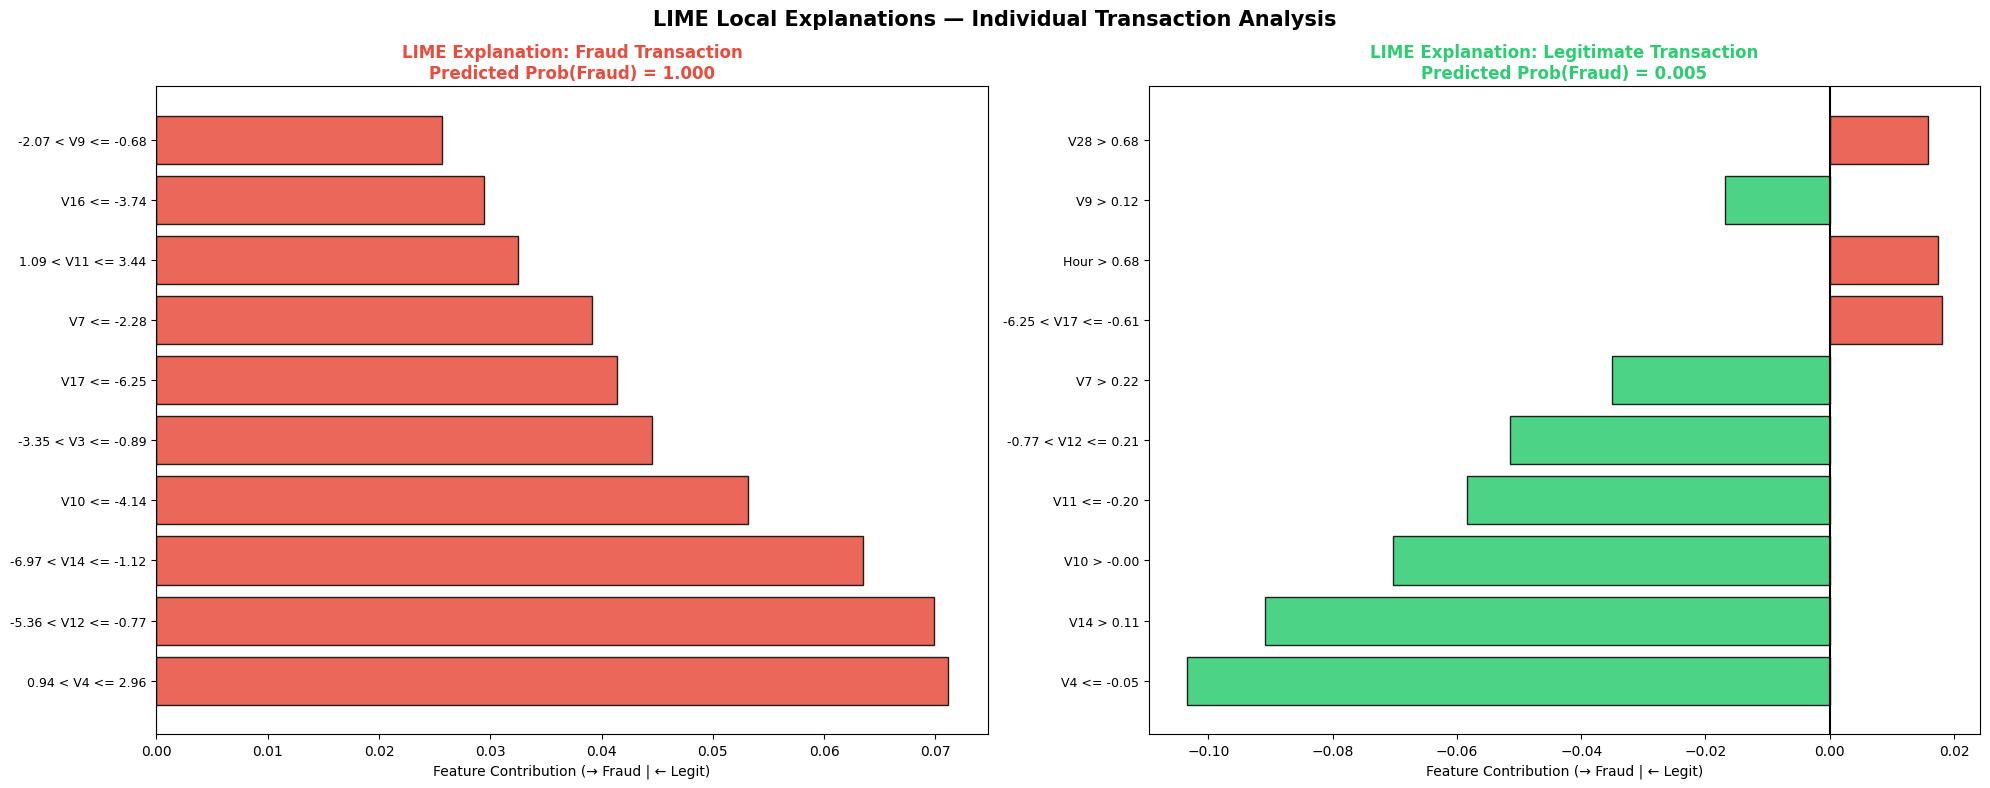

 LIME analysis complete. Figure 4 saved


In [10]:
print(" Running LIME explainer")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled,
    feature_names=feature_names,
    class_names=['Legitimate', 'Fraud'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

fraud_test_idx = np.where(y_test == 1)[0][0]
legit_test_idx = np.where(y_test == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('LIME Local Explanations — Individual Transaction Analysis',fontsize=15, fontweight='bold')

for ax, idx, label, color in zip(
    axes,
    [fraud_test_idx, legit_test_idx],
    ['Fraud Transaction', 'Legitimate Transaction'],
    ['#e74c3c', '#2ecc71']
):
    exp = lime_explainer.explain_instance(
        X_test_scaled[idx],
        best_model.predict_proba,
        num_features=10,
        num_samples=1000
    )

    exp_list = exp.as_list(label=1)
    features_lime = [x[0][:30] for x in exp_list]
    values_lime = [x[1] for x in exp_list]
    lime_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in values_lime]

    bars = ax.barh(range(len(features_lime)), values_lime,
                   color=lime_colors, alpha=0.85, edgecolor='black')
    ax.set_yticks(range(len(features_lime)))
    ax.set_yticklabels(features_lime, fontsize=9)
    ax.axvline(x=0, color='black', lw=1.5)
    ax.set_title(f'LIME Explanation: {label}\n'
                 f'Predicted Prob(Fraud) = {best_model.predict_proba(X_test_scaled[idx:idx+1])[0][1]:.3f}',
                 fontweight='bold', color=color)
    ax.set_xlabel('Feature Contribution (→ Fraud | ← Legit)')

plt.tight_layout()
plt.savefig('fig4_lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print(" LIME analysis complete. Figure 4 saved")

fairness audit

 FAIRNESS AUDIT

 Per-Group Metrics:
                     F1 Score  Selection Rate
sensitive_feature_0                          
High-spend             0.6667          0.0029
Low-spend              0.8155          0.0028
Mid-spend              0.7200          0.0007

 Overall Metrics:
F1 Score          0.7421
Selection Rate    0.0022
dtype: float64

 Demographic Parity Difference: 0.0022
Equalized Odds Difference: 0.0414

(Values closer to 0 = more fair. |DPD| > 0.1 is a fairness concern)


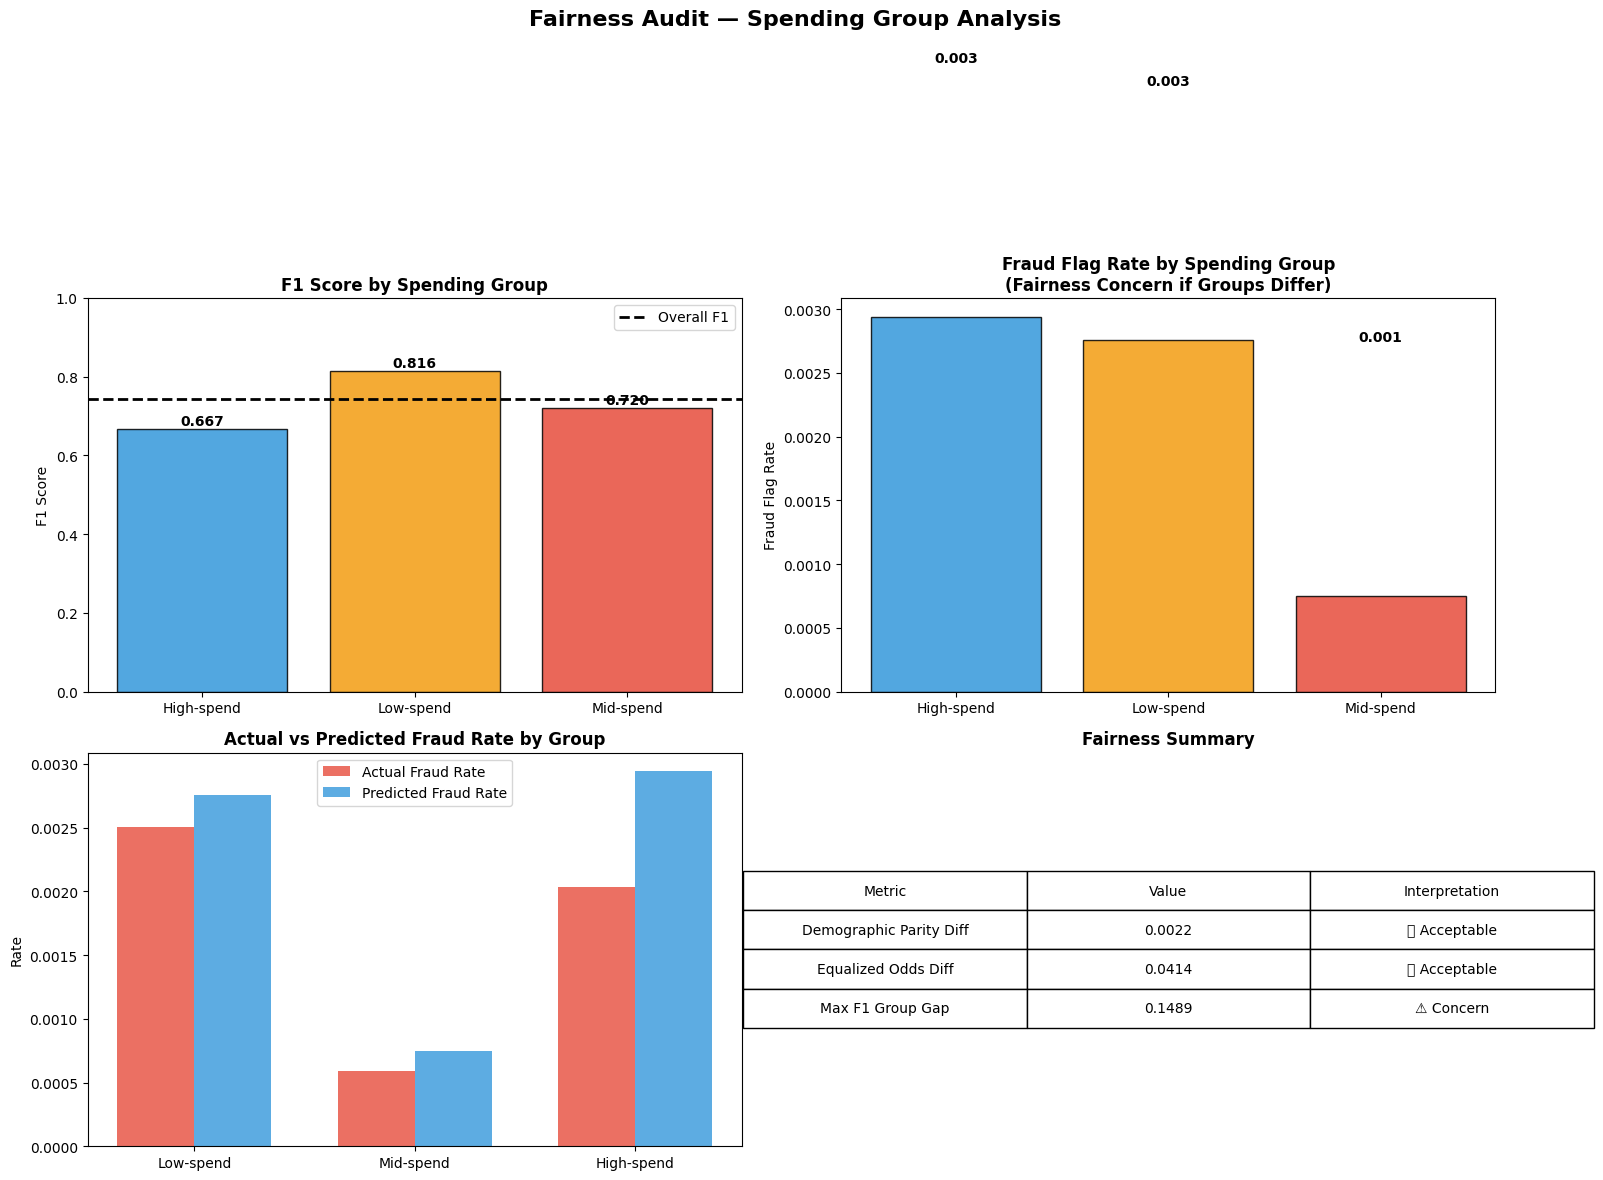

Fairness audit complete. Figure 5 saved.


In [11]:
print("="*50)
print(" FAIRNESS AUDIT")
print("="*50)

y_pred_best = results[best_model_name]['y_pred']
y_prob_best = results[best_model_name]['y_prob']

metric_frame = MetricFrame(
    metrics={
        'F1 Score': f1_score,
        'Selection Rate': selection_rate,
    },
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sf_test
)

print("\n Per-Group Metrics:")
print(metric_frame.by_group.round(4))
print(f"\n Overall Metrics:")
print(metric_frame.overall.round(4))

dpd = demographic_parity_difference(y_test, y_pred_best, sensitive_features=sf_test)
eod = equalized_odds_difference(y_test, y_pred_best, sensitive_features=sf_test)
print(f"\n Demographic Parity Difference: {dpd:.4f}")
print(f"Equalized Odds Difference: {eod:.4f}")
print("\n(Values closer to 0 = more fair. |DPD| > 0.1 is a fairness concern)")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Fairness Audit — Spending Group Analysis',fontsize=16, fontweight='bold')

groups = df['spending_group'].cat.categories.tolist()
group_colors = ['#3498db', '#f39c12', '#e74c3c']

f1_per_group = metric_frame.by_group['F1 Score']
axes[0,0].bar(f1_per_group.index, f1_per_group.values,color=group_colors, alpha=0.85, edgecolor='black')
axes[0,0].axhline(y=results[best_model_name]['f1'], color='black',linestyle='--', lw=2, label='Overall F1')
axes[0,0].set_title('F1 Score by Spending Group', fontweight='bold')
axes[0,0].set_ylabel('F1 Score')
axes[0,0].set_ylim(0, 1)
axes[0,0].legend()
for i, (k, v) in enumerate(f1_per_group.items()):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

sr_per_group = metric_frame.by_group['Selection Rate']
axes[0,1].bar(sr_per_group.index, sr_per_group.values,color=group_colors, alpha=0.85, edgecolor='black')
axes[0,1].set_title('Fraud Flag Rate by Spending Group\n(Fairness Concern if Groups Differ)',fontweight='bold')
axes[0,1].set_ylabel('Fraud Flag Rate')
for i, (k, v) in enumerate(sr_per_group.items()):
    axes[0,1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

actual_fraud_rate = pd.Series(y_test, index=range(len(y_test))).values
sf_series = pd.Series(sf_test)
actual_rates = {}
predicted_rates = {}
for g in groups:
    mask = sf_series.values == g
    if mask.sum() > 0:
        actual_rates[g] = y_test[mask].mean()
        predicted_rates[g] = y_pred_best[mask].mean()

x_pos = np.arange(len(groups))
width = 0.35
axes[1,0].bar(x_pos - width/2, [actual_rates.get(g, 0) for g in groups],width, label='Actual Fraud Rate', color='#e74c3c', alpha=0.8)
axes[1,0].bar(x_pos + width/2, [predicted_rates.get(g, 0) for g in groups],width, label='Predicted Fraud Rate', color='#3498db', alpha=0.8)
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(groups)
axes[1,0].set_title('Actual vs Predicted Fraud Rate by Group', fontweight='bold')
axes[1,0].set_ylabel('Rate')
axes[1,0].legend()

ax = axes[1,1]
ax.axis('off')
fairness_summary = [
    ['Metric', 'Value', 'Interpretation'],
    ['Demographic Parity Diff', f'{dpd:.4f}',
     '⚠️ Concern' if abs(dpd) > 0.1 else '✅ Acceptable'],
    ['Equalized Odds Diff', f'{eod:.4f}',
     '⚠️ Concern' if abs(eod) > 0.1 else '✅ Acceptable'],
    ['Max F1 Group Gap',
     f"{max(f1_per_group.values) - min(f1_per_group.values):.4f}",
     '⚠️ Concern' if max(f1_per_group.values) - min(f1_per_group.values) > 0.1
     else '✅ Acceptable'],
]
t = ax.table(cellText=fairness_summary[1:], colLabels=fairness_summary[0],loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(10)
t.scale(1.3, 2.5)
ax.set_title('Fairness Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fairness audit complete. Figure 5 saved.")

final summery dashboard

In [13]:
print("\n" + "="*60)
print(" FINAL RESEARCH SUMMARY")
print("="*60)

summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'F1 Score': [results[m]['f1'] for m in results],
    'AUC-ROC': [results[m]['auc_roc'] for m in results],
    'Avg Precision': [results[m]['avg_precision'] for m in results],
    'MCC': [results[m]['mcc'] for m in results],
}).sort_values('AUC-ROC', ascending=False)

summary_df = summary_df.reset_index(drop=True)
summary_df.index += 1
print(summary_df.round(4).to_string())

print(f"\n Best Model: {best_model_name}")
print(f"   AUC-ROC:       {results[best_model_name]['auc_roc']:.4f}")
print(f"   F1 Score:      {results[best_model_name]['f1']:.4f}")
print(f"   Avg Precision: {results[best_model_name]['avg_precision']:.4f}")
print(f"   MCC:           {results[best_model_name]['mcc']:.4f}")

print(f"\n Fairness Findings:")
print(f"   Demographic Parity Difference: {dpd:.4f}")
print(f"   Equalized Odds Difference:     {eod:.4f}")

print(f"\n Saved Figures:")
figs = [
    "fig1_dataset_overview.png",
    "fig2_model_comparison.png",
    "fig3a_shap_beeswarm.png",
    "fig3b_shap_importance.png",
    "fig3c_shap_waterfall.png",
    "fig4_lime_explanations.png",
    "fig5_fairness_audit.png"
]
for f in figs:
    print(f"{f}")

print("\n FULL PIPELINE COMPLETE.")


 FINAL RESEARCH SUMMARY
                 Model  F1 Score  AUC-ROC  Avg Precision     MCC
1        Random Forest    0.7421   0.9847         0.8489  0.7464
2              XGBoost    0.2638   0.9820         0.8422  0.3671
3             LightGBM    0.7623   0.9748         0.8608  0.7675
4  Logistic Regression    0.1040   0.9711         0.7188  0.2214

 Best Model: Random Forest
   AUC-ROC:       0.9847
   F1 Score:      0.7421
   Avg Precision: 0.8489
   MCC:           0.7464

 Fairness Findings:
   Demographic Parity Difference: 0.0022
   Equalized Odds Difference:     0.0414

 Saved Figures:
fig1_dataset_overview.png
fig2_model_comparison.png
fig3a_shap_beeswarm.png
fig3b_shap_importance.png
fig3c_shap_waterfall.png
fig4_lime_explanations.png
fig5_fairness_audit.png

 FULL PIPELINE COMPLETE.
